Experience-Driven Salary Estimation


1. Import Required Libraries

In [1]:
import numpy as np  # For numerical computations
import matplotlib.pyplot as plt  # For data visualization
import pandas as pd  # For handling datasets

2. Load and Explore the Dataset


In [2]:
dataset = pd.read_csv('Salary_Data.csv')

# splitting the data into the independent and dependent set
X = dataset.iloc[:, :-1].values  # Independent variable (Years of Experience)
y = dataset.iloc[:, -1].values   # Dependent variable (Salary)

3. Split Data into Training and Testing Sets

In [3]:
from sklearn.model_selection import train_test_split  # Import when needed
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=0)

4. Feature Scaling (Standardization)

In [4]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

5. Train the Linear Regression Model

In [5]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


6. Make Predictions

In [6]:
y_pred = regressor.predict(X_test)

7. Visualize Results
Training Set Visualization

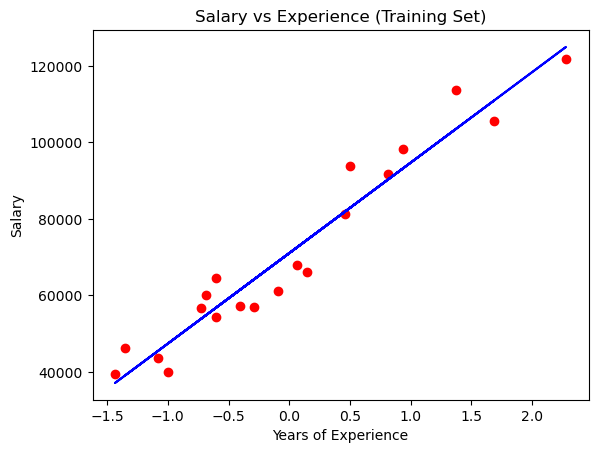

In [7]:
plt.scatter(X_train, y_train, color='red')  # Actual salaries
plt.plot(X_train, regressor.predict(X_train), color='blue')  # Regression line
plt.title('Salary vs Experience (Training Set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

Observation: The blue regression line fits the red data points well, showing a clear upward trend.

Test Set Visualization

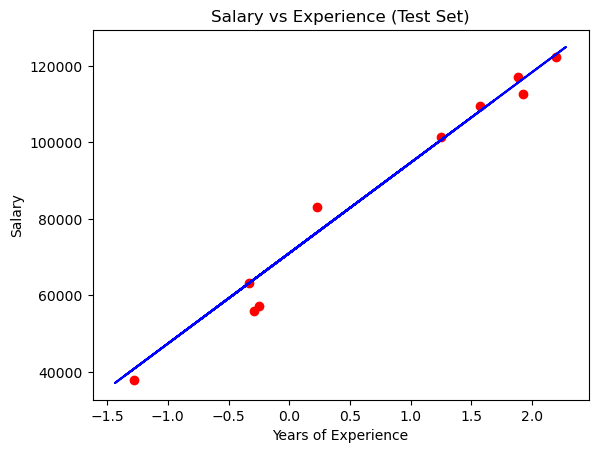

In [8]:
plt.scatter(X_test, y_test, color='red')  # Actual salaries
plt.plot(X_train, regressor.predict(X_train), color='blue')  # Regression line
plt.title('Salary vs Experience (Test Set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

Observation: The model generalizes well - test points lie close to the regression line.

8. Evaluate Model Performance

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Import when needed
mae = mean_absolute_error(y_test, y_pred)  # Measures absolute difference between actual and predicted values
mse = mean_squared_error(y_test, y_pred)  # Measures the squared difference (penalizes large errors more)
r2 = r2_score(y_test, y_pred)  # Measures how well the model explains variance in the data


In [10]:
# Printing performance metrics
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared Score (R²): {r2}")

Mean Absolute Error (MAE): 3426.4269374307128
Mean Squared Error (MSE): 21026037.329511296
R-squared Score (R²): 0.9749154407708353


 Evaluation Results
Metric	Value	What it tells us
MAE	3,426.43	Average prediction error is ~$3,426
MSE	21,026,037.33	Larger errors are penalized more
R²	0.9749	Model explains 97.5% of salary variance
Interpretation: An R² of 0.975 means experience alone explains almost all the variation in salary - a very strong linear relationship!

 Key Takeaways
✅ Strong linear relationship between experience and salary
✅ Low prediction error relative to salary range ($30k-$120k)
✅ No overfitting - consistent performance on test data
✅ Model is ready for predicting salaries from years of experience



Predicting salary for 5 years of experience

In [11]:
# Example: Predict salary for 5 years of experience
exp = np.array([[5]])
exp_scaled = sc_X.transform(exp)
predicted_salary = regressor.predict(exp_scaled)
print(f"Predicted salary: ${predicted_salary[0]:,.2f}")

Predicted salary: $73,545.90
